# 01 – Exploratory Data Analysis (EDA)

Goal: Overview of revenue data (Net Value, Quantity) and macroeconomic time series for DE and US.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid')

# Paths to raw data
DATA_RAW = '../data/raw/'

---
## 1. German Macro Data (Destatis)

### 1.1 DE – Orders Received Index (DGORDER Domestic, Destatis 42151-0004)

In [2]:
# Load DE DGORDER – skip first row (SAC export header 'sep=,')
de_dgorder = pd.read_csv(
    DATA_RAW + 'DGE_DE_DGORDER.csv',
    skiprows=1
)

# Rename value column for clarity
de_dgorder = de_dgorder.rename(columns={
    'X13_JDemetra__kalender__und_saisonbereinigt': 'orders_index'
})

# Parse date and set as index
de_dgorder['DateId'] = pd.to_datetime(de_dgorder['DateId'], format='%Y-%m')
de_dgorder = de_dgorder[['DateId', 'orders_index']].dropna()

print('Shape:', de_dgorder.shape)
print('\nColumn dtypes:')
print(de_dgorder.dtypes)
print('\nMissing values:')
print(de_dgorder.isnull().sum())
print('\nFirst 5 rows:')
de_dgorder.head()

Shape: (97, 2)

Column dtypes:
DateId          datetime64[us]
orders_index           float64
dtype: object

Missing values:
DateId          0
orders_index    0
dtype: int64

First 5 rows:


,DateId,orders_index
0,2018-01-01,97.7
1,2018-02-01,95.8
2,2018-03-01,97.9
3,2018-04-01,95.4
4,2018-05-01,97.5


### 1.2 DE – Industrial Production Index (Destatis 42153-0001)

In [3]:
# Load DE INDPRO – skip first row (SAC export header 'sep=,')
de_indpro = pd.read_csv(
    DATA_RAW + 'DGE_DE_INDPRO.csv',
    skiprows=1
)

# Rename value column for clarity
de_indpro = de_indpro.rename(columns={
    'X13_JDemetra___kalender__und_saisonbereinigt': 'production_index'
})

# Parse date and set as index
de_indpro['DateId'] = pd.to_datetime(de_indpro['DateId'], format='%Y-%m')
de_indpro = de_indpro[['DateId', 'production_index']].dropna()

print('Shape:', de_indpro.shape)
print('\nColumn dtypes:')
print(de_indpro.dtypes)
print('\nMissing values:')
print(de_indpro.isnull().sum())
print('\nFirst 5 rows:')
de_indpro.head()

Shape: (97, 2)

Column dtypes:
DateId              datetime64[us]
production_index           float64
dtype: object

Missing values:
DateId              0
production_index    0
dtype: int64

First 5 rows:


,DateId,production_index
0,2018-01-01,107.2
1,2018-02-01,104.9
2,2018-03-01,106.4
3,2018-04-01,106.2
4,2018-05-01,108.0


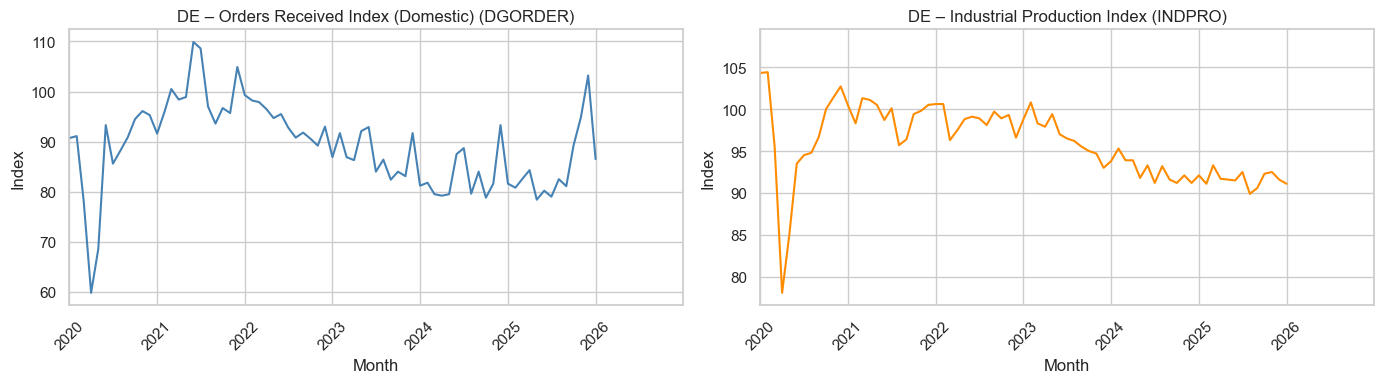

In [5]:
# Plot both German macro indicators side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(de_dgorder['DateId'], de_dgorder['orders_index'], color='steelblue')
axes[0].set_title('DE – Orders Received Index (Domestic) (DGORDER)')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Index')
axes[0].set_xlim(pd.Timestamp('2020-01-01'), pd.Timestamp('2026-12-31'))
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(de_indpro['DateId'], de_indpro['production_index'], color='darkorange')
axes[1].set_title('DE – Industrial Production Index (INDPRO)')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Index')
axes[1].set_xlim(pd.Timestamp('2020-01-01'), pd.Timestamp('2026-12-31'))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---
## 2. US Macro Data (FRED)

### 2.1 US – Durable Goods Orders (FRED DGORDER)

In [6]:
# Load US DGORDER – skip first row (SAC export header 'sep=,')
us_dgorder = pd.read_csv(
    DATA_RAW + 'DGE_US_DGORDER.csv',
    skiprows=1
)

# Parse date and keep only relevant columns
us_dgorder['observation_dateDATE'] = pd.to_datetime(us_dgorder['observation_dateDATE'])
us_dgorder = us_dgorder[['observation_dateDATE', 'DGORDER']].rename(
    columns={'observation_dateDATE': 'date', 'DGORDER': 'durable_goods_orders_musd'}
)

print('Shape:', us_dgorder.shape)
print('\nColumn dtypes:')
print(us_dgorder.dtypes)
print('\nMissing values:')
print(us_dgorder.isnull().sum())
print('\nDate range:', us_dgorder['date'].min(), '–', us_dgorder['date'].max())
print('\nFirst 5 rows:')
us_dgorder.head()

Shape: (407, 2)

Column dtypes:
date                         datetime64[us]
durable_goods_orders_musd             int64
dtype: object

Missing values:
date                         0
durable_goods_orders_musd    0
dtype: int64

Date range: 1992-02-01 00:00:00 – 2025-12-01 00:00:00

First 5 rows:


,date,durable_goods_orders_musd
0,1992-02-01,114535
1,1992-03-01,120025
2,1992-04-01,124470
3,1992-05-01,125822
4,1992-06-01,122834


### 2.2 US – Industrial Production Index (FRED INDPRO)

In [7]:
# Load US INDPRO – skip first row (SAC export header 'sep=,')
# Filter to 2018+ to align with the DE series and revenue data
us_indpro = pd.read_csv(
    DATA_RAW + 'DGE_US_INDPRO.csv',
    skiprows=1
)

us_indpro['observation_dateDATE'] = pd.to_datetime(us_indpro['observation_dateDATE'])
us_indpro = us_indpro[['observation_dateDATE', 'INDPRO']].rename(
    columns={'observation_dateDATE': 'date', 'INDPRO': 'industrial_production_index'}
)

print('Shape (full history):', us_indpro.shape)
print('Full date range:', us_indpro['date'].min(), '–', us_indpro['date'].max())
print('\nColumn dtypes:')
print(us_indpro.dtypes)
print('\nMissing values:')
print(us_indpro.isnull().sum())

# Restrict to 2018+ for comparability
us_indpro_recent = us_indpro[us_indpro['date'] >= '2018-01-01'].copy()
print('\nShape (2018+):', us_indpro_recent.shape)
us_indpro_recent.head()

Shape (full history): (1285, 2)
Full date range: 1919-01-01 00:00:00 – 2026-01-01 00:00:00

Column dtypes:
date                           datetime64[us]
industrial_production_index           float64
dtype: object

Missing values:
date                           0
industrial_production_index    0
dtype: int64

Shape (2018+): (97, 2)


,date,industrial_production_index
1188,2018-01-01,101.4625
1189,2018-02-01,101.7085
1190,2018-03-01,102.2067
1191,2018-04-01,103.3329
1192,2018-05-01,102.4024


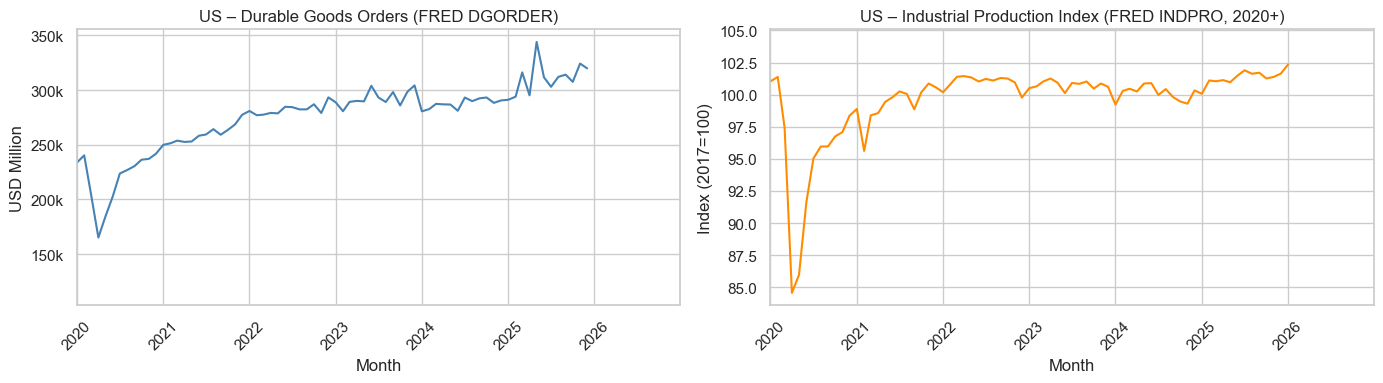

In [8]:
# Plot US macro indicators
# Both restricted to 2020–2026 for consistency
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(us_dgorder['date'], us_dgorder['durable_goods_orders_musd'], color='steelblue')
axes[0].set_title('US – Durable Goods Orders (FRED DGORDER)')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('USD Million')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
axes[0].set_xlim(pd.Timestamp('2020-01-01'), pd.Timestamp('2026-12-31'))
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(us_indpro_recent['date'], us_indpro_recent['industrial_production_index'], color='darkorange')
axes[1].set_title('US – Industrial Production Index (FRED INDPRO, 2020+)')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Index (2017=100)')
axes[1].set_xlim(pd.Timestamp('2020-01-01'), pd.Timestamp('2026-12-31'))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---
## 3. Revenue Data (SAP Analytics Cloud Export)

### 3.1 Net Value (USD)

In [9]:
# Load Net Value XLSX – first sheet contains active data
net_value = pd.read_excel(
    DATA_RAW + 'DGE_Revenue_Planning_Actuals_Net_Value_US.xlsx',
    sheet_name=0
)

# Rename value column (SAC export places the value in 'Unnamed: 4')
net_value = net_value.rename(columns={'Unnamed: 4': 'net_value_usd'})

# Parse YYYYMM integer date to datetime
net_value['date'] = pd.to_datetime(net_value['Date'].astype(str), format='%Y%m')

print('Shape:', net_value.shape)
print('\nColumn dtypes:')
print(net_value.dtypes)
print('\nMissing values:')
print(net_value.isnull().sum())
print('\nProducts:', net_value['Product'].unique())
print('\nFirst 5 rows:')
net_value.head()

Shape: (78, 6)

Column dtypes:
Date                      int64
Country                     str
Product                     str
Measures                    str
net_value_usd           float64
date             datetime64[us]
dtype: object

Missing values:
Date             0
Country          0
Product          0
Measures         0
net_value_usd    0
date             0
dtype: int64

Products: <StringArray>
['Accessories', 'Compressors']
Length: 2, dtype: str

First 5 rows:


,Date,Country,Product,Measures,net_value_usd,date
0,202210,US,Accessories,Net Value,1868.72,2022-10-01
1,202210,US,Compressors,Net Value,2353253.00,2022-10-01
2,202211,US,Accessories,Net Value,-556.05,2022-11-01
3,202211,US,Compressors,Net Value,2250209.00,2022-11-01
4,202212,US,Accessories,Net Value,4277.21,2022-12-01


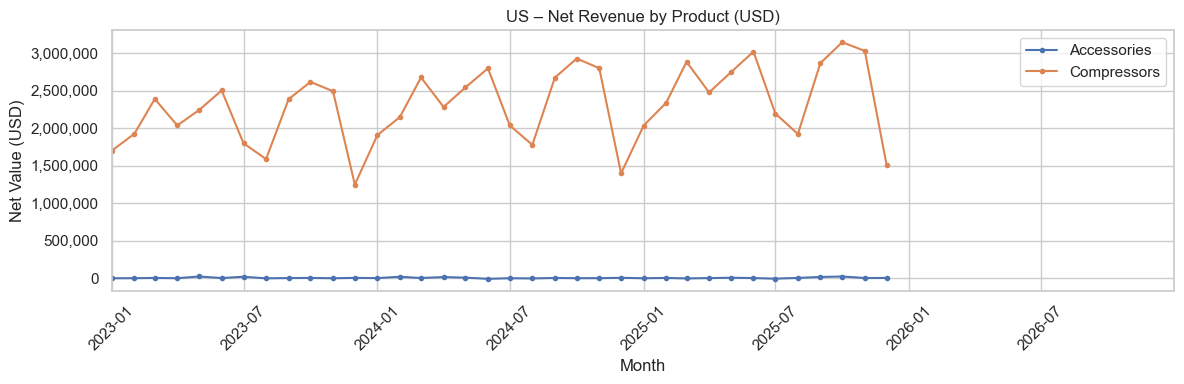

In [11]:
# Plot Net Value over time, split by product
fig, ax = plt.subplots(figsize=(12, 4))

for product, group in net_value.groupby('Product'):
    ax.plot(group['date'], group['net_value_usd'], marker='o', markersize=3, label=product)

ax.set_title('US – Net Revenue by Product (USD)')
ax.set_xlabel('Month')
ax.set_ylabel('Net Value (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xlim(pd.Timestamp('2023-01-01'), pd.Timestamp('2026-12-31'))
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

### 3.2 Order Quantity

In [12]:
# Load Quantity XLSX – first sheet contains active data
quantity = pd.read_excel(
    DATA_RAW + 'DGE_Revenue_Planning_Actuals_Quantity_US.xlsx',
    sheet_name=0
)

# Rename value column
quantity = quantity.rename(columns={'Unnamed: 4': 'order_quantity'})

# Parse YYYYMM integer date to datetime
quantity['date'] = pd.to_datetime(quantity['Date'].astype(str), format='%Y%m')

print('Shape:', quantity.shape)
print('\nColumn dtypes:')
print(quantity.dtypes)
print('\nMissing values:')
print(quantity.isnull().sum())
print('\nProducts:', quantity['Product'].unique())
print('\nFirst 5 rows:')
quantity.head()

Shape: (78, 6)

Column dtypes:
Date                       int64
Country                      str
Product                      str
Measures                     str
order_quantity             int64
date              datetime64[us]
dtype: object

Missing values:
Date              0
Country           0
Product           0
Measures          0
order_quantity    0
date              0
dtype: int64

Products: <StringArray>
['Accessories', 'Compressors']
Length: 2, dtype: str

First 5 rows:


,Date,Country,Product,Measures,order_quantity,date
0,202210,US,Accessories,Order Quantity,205,2022-10-01
1,202210,US,Compressors,Order Quantity,3258,2022-10-01
2,202211,US,Accessories,Order Quantity,135,2022-11-01
3,202211,US,Compressors,Order Quantity,4584,2022-11-01
4,202212,US,Accessories,Order Quantity,260,2022-12-01


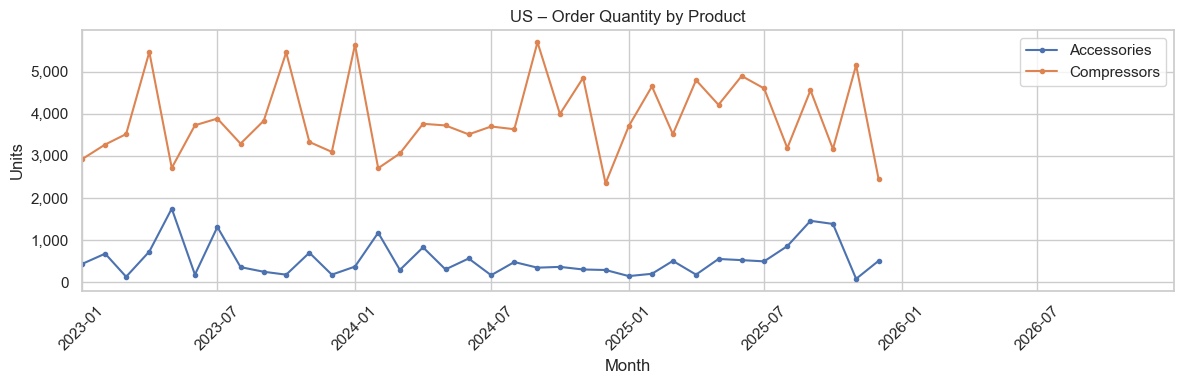

In [14]:
# Plot Order Quantity over time, split by product
fig, ax = plt.subplots(figsize=(12, 4))

for product, group in quantity.groupby('Product'):
    ax.plot(group['date'], group['order_quantity'], marker='o', markersize=3, label=product)

ax.set_title('US – Order Quantity by Product')
ax.set_xlabel('Month')
ax.set_ylabel('Units')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xlim(pd.Timestamp('2023-01-01'), pd.Timestamp('2026-12-31'))
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. Summary

| Dataset | Rows | Date Range | Key Column |
|---|---|---|---|
| DE DGORDER (Destatis) | ~96 | 2018-01 – 2026-01 | `orders_index` |
| DE INDPRO (Destatis) | ~96 | 2018-01 – 2026-01 | `production_index` |
| US DGORDER (FRED) | ~406 | 1992-02 – 2025-12 | `durable_goods_orders_musd` |
| US INDPRO (FRED) | ~1284 | 1919-01 – 2025-12 | `industrial_production_index` |
| Net Value (SAC) | 78 | 2022-10 – 2025-12 | `net_value_usd` |
| Quantity (SAC) | 78 | 2022-10 – 2025-12 | `order_quantity` |

**Notes:**
- All CSV files use SAC export format (`sep=,` first line → `skiprows=1`)
- US INDPRO has long historical series back to 1919; restrict to 2018+ for modelling
- DGORDER remains in USD millions (XGBoost is scale-invariant – no normalization needed)
- Revenue data covers 2 products: Accessories and Compressors